# Task-routed: within-phase signal test (A↔B via recurrence)

**Goal:** Quickly see whether **existing** `sim_*.npz` logs contain a **usable signal** for:

1. **During B (phase 1):** Input is routed to module B only, but recurrence can carry **A→B** influence. *Look for:* non-flat **module-0** hidden activity/norms while `feature_probe==1`, and how it co-varies with B loss/accuracy.
2. **During A2 (phase 2):** Gradients apply only on **probe-0** trials; **probe-1** trials still run the full graph. *Look for:* differences in hidden statistics between **update** vs **eval-only** streams → **B→A** (and readout) effects on the state you care about.
3. **Post-phase snapshots (optional):** `*_core_per_module` / `*_comms_per_module` at phase boundaries → how much “pathway” vs local core state on the **ordered sweep** (not every training step).

**Not claimed:** Causal attribution (for that, add ablations or `return_core_comms` on training batches). This notebook is a **screening** tool.

**Configure** the run folder and participant in the next section; rerun all cells below.

After loading one `npz`, a **Quick overview** section scans **every** `sim_*.npz` in the same folder (table + histograms) so you can compare participants at a glance.

In [1]:
import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

sim_folder = project_root / "data" / "simulations"
config_path = project_root / "a1b2" / "models" / "experiments.json"
with open(config_path, "r") as f:
    experiments = json.load(f)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

try:
    from IPython.display import display
except ImportError:
    display = print

print("Project root:", project_root)
print("Simulations root:", sim_folder)

Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations


## Configure run and participant

- Set `RUN_FOLDER` to a directory that contains `sim_<participant>.npz` (e.g. a `two_module_rnn_*_task_routed_*` run).
- Leave `PARTICIPANT_ID` as `None` to auto-pick the first `sim_*.npz` in that folder.

In [2]:
# --- edit these ---
RUN_FOLDER = sim_folder / "two_module_rnn_25_task_routed_nb2_nb2_task_routed_sp1_sep_cr_RNN"  # change if missing
PARTICIPANT_ID = None  # e.g. "geom_sub_same_1" or None for first match
# -------------------

def find_task_routed_runs(root: Path, max_n=12):
    """List run dirs that look task-routed (heuristic: folder name contains task_routed)."""
    if not root.is_dir():
        return []
    out = []
    for p in sorted(root.iterdir()):
        if p.is_dir() and "task_routed" in p.name.lower():
            if any(p.glob("sim_*.npz")):
                out.append(p)
        if len(out) >= max_n:
            break
    return out

if not RUN_FOLDER.is_dir() or not any(RUN_FOLDER.glob("sim_*.npz")):
    candidates = find_task_routed_runs(sim_folder)
    if candidates:
        RUN_FOLDER = candidates[0]
        print("RUN_FOLDER not found or empty; using:", RUN_FOLDER)
    else:
        print(
            "No sim_*.npz under RUN_FOLDER and no task_routed folders found."
            " Point RUN_FOLDER at a completed simulation directory."
        )

npz_files = sorted(RUN_FOLDER.glob("sim_*.npz"))
if not npz_files:
    raise FileNotFoundError(f"No sim_*.npz in {RUN_FOLDER}")

if PARTICIPANT_ID is None:
    PARTICIPANT_ID = npz_files[0].stem.replace("sim_", "")

NPZ_PATH = RUN_FOLDER / f"sim_{PARTICIPANT_ID}.npz"
if not NPZ_PATH.is_file():
    raise FileNotFoundError(NPZ_PATH)

settings_path = RUN_FOLDER / "settings.json"
if settings_path.is_file():
    with open(settings_path) as f:
        run_settings = json.load(f)
    cond = run_settings.get("condition", {})
    print("input_routing:", cond.get("input_routing", "?"))
    print("sparsity:", cond.get("sparsity", "?"))
else:
    run_settings = None
    print("(no settings.json)")

print("NPZ:", NPZ_PATH)

input_routing: task_routed
sparsity: 1
NPZ: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/two_module_rnn_25_task_routed_nb2_nb2_task_routed_sp1_sep_cr_RNN/sim_study1_far_sub1.npz


## Load arrays and validate shapes

Expected: `losses`, `accuracy`, `probes` → `(n_phase, n_trials)`; `hiddens_per_module` → `(n_phase, n_trials, n_modules, hidden_size)` for two-module RNN saves.

In [3]:
def load_sim_npz(path: Path):
    with np.load(path, allow_pickle=True) as z:
        data = {k: z[k] for k in z.files}
    return data


def trial_mask_1d(a):
    """Boolean mask of trials with finite values (phase slice)."""
    x = np.asarray(a, dtype=float)
    return np.isfinite(x)


def rolling_mean(x, window=20):
    x = np.asarray(x, dtype=float)
    s = pd.Series(x)
    return s.rolling(window=window, min_periods=max(1, window // 4)).mean().to_numpy()


data = load_sim_npz(NPZ_PATH)
need = ["losses", "accuracy", "probes"]
missing = [k for k in need if k not in data]
if missing:
    raise KeyError(f"npz missing keys {missing}. Available: {sorted(data.keys())[:30]}...")

losses = data["losses"]
acc = data["accuracy"]
probes = data["probes"]
print("losses", losses.shape, "accuracy", acc.shape, "probes", probes.shape)

has_hpm = "hiddens_per_module" in data
if has_hpm:
    hpm = data["hiddens_per_module"]
    print("hiddens_per_module", hpm.shape)
else:
    hpm = None
    print("WARN: no hiddens_per_module — module plots skipped (old run or non-RNN).")

PHASE_A1, PHASE_B, PHASE_A2 = 0, 1, 2
MOD_A, MOD_B = 0, 1

losses (3, 12000) accuracy (3, 12000) probes (3, 12000)
hiddens_per_module (3, 12000, 2, 25)


## Quick overview — all participants in `RUN_FOLDER`

Aggregates **one row per `sim_*.npz`** so you can see distributions without opening each file.

**Metrics:**
- **B phase, probe 1 only** (B-routed): median ‖h_A‖/‖h_B‖, mean loss/acc (if `hiddens_per_module` present).
- **B phase, all trials** (mixed probes): same norm ratio (often misleading if probe 0 and 1 are interleaved).
- **A2**: mean loss/acc for probe 0 vs 1 and **loss gap** (p1−p0).
- **core/comms** keys present? (yes/no)

Re-run after changing `RUN_FOLDER` in the config cell above.

Overview: 305 npz files in two_module_rnn_25_task_routed_nb2_nb2_task_routed_sp1_sep_cr_RNN


,participant,b_n_valid,b_n_probe_0,b_n_probe_1,b_median_hA_over_hB_all,b_median_hA_over_hB_probe1,b_mean_loss_probe1,b_mean_acc_probe1,a2_mean_loss_probe0,a2_mean_acc_probe0,a2_mean_loss_probe1,a2_mean_acc_probe1,a2_loss_gap_p1_minus_p0,has_core_comms_keys
0,study1_far_sub1,12000,6000,6000,1.870201,0.187084,0.006328,0.996358,0.000304,0.999627,0.168086,0.845347,0.167782,False
1,study1_far_sub10,12000,6000,6000,1.889576,0.234408,0.006601,0.995230,0.000229,0.999671,0.111707,0.921270,0.111478,False
2,study1_far_sub12,12000,6000,6000,1.949189,0.205699,0.007910,0.993741,0.000163,0.999523,0.158604,0.841679,0.158441,False
3,study1_far_sub13,12000,6000,6000,2.029413,0.267468,0.006315,0.996598,0.000291,0.999552,0.088712,0.942086,0.088421,False
4,study1_far_sub15,12000,6000,6000,2.200455,0.197917,0.009798,0.992385,0.000198,0.999724,0.155004,0.864191,0.154806,False
5,study1_far_sub16,12000,6000,6000,1.785610,0.229535,0.006659,0.995932,0.000307,0.999536,0.137772,0.876042,0.137465,False
6,study1_far_sub19,12000,6000,6000,2.242940,0.196360,0.009481,0.992914,0.000246,0.999513,0.122220,0.904207,0.121974,False
7,study1_far_sub20,12000,6000,6000,2.171675,0.224105,0.007708,0.993811,0.000294,0.999436,0.147626,0.885621,0.147332,False
8,study1_far_sub21,12000,6000,6000,2.451818,0.192301,0.009100,0.993251,0.000262,0.999645,0.069184,0.962232,0.068922,False
9,study1_far_sub22,12000,6000,6000,2.269910,0.201499,0.007290,0.994409,0.000192,0.999685,0.154365,0.887765,0.154174,False


,count,mean,std,min,25%,50%,75%,max
b_n_valid,305.0,12000.000000,0.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
b_n_probe_0,305.0,6000.000000,0.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
b_n_probe_1,305.0,6000.000000,0.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
b_median_hA_over_hB_all,305.0,2.111425,0.176159,1.540282,1.989883,2.116065,2.226894,2.645488
b_median_hA_over_hB_probe1,305.0,0.204395,0.017380,0.160681,0.192317,0.201948,0.216807,0.267468
b_mean_loss_probe1,305.0,0.007334,0.001378,0.003936,0.006295,0.007210,0.008083,0.011792
b_mean_acc_probe1,305.0,0.995051,0.001325,0.991257,0.994227,0.995129,0.996015,0.998488
a2_mean_loss_probe0,305.0,0.000243,0.000054,0.000114,0.000206,0.000232,0.000279,0.000442
a2_mean_acc_probe0,305.0,0.999566,0.000135,0.998990,0.999489,0.999581,0.999661,0.999852
a2_mean_loss_probe1,305.0,0.142481,0.043131,0.045193,0.111535,0.140615,0.168028,0.260276


/tmp/ipykernel_2643349/438167083.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


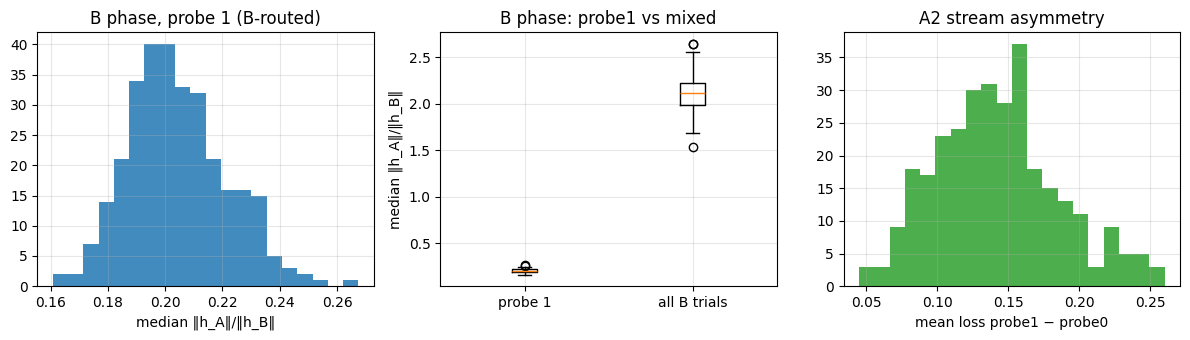

npz with core/comms post-phase keys: 0 / 305


In [4]:
def summarize_npz_for_overview(path: Path, phase_b=1, phase_a2=2):
    """Return a flat dict of screening metrics for one sim file."""
    row = {"participant": path.stem.replace("sim_", ""), "path": str(path.name)}
    try:
        d = load_sim_npz(path)
    except Exception as e:
        row["error"] = str(e)
        return row

    for k in ("losses", "accuracy", "probes"):
        if k not in d:
            row["error"] = f"missing {k}"
            return row

    losses = d["losses"]
    acc = d["accuracy"]
    probes = d["probes"]
    hpm = d.get("hiddens_per_module")
    mod_a, mod_b = 0, 1  # modules A / B (matches MOD_A/MOD_B below)

    def phase_masks(phase):
        m = trial_mask_1d(losses[phase])
        p = probes[phase, m].astype(int)
        return m, p

    m_b, pr_b = phase_masks(phase_b)
    u, cts = np.unique(pr_b, return_counts=True)
    row["b_n_valid"] = int(m_b.sum())
    for uu, cc in zip(u, cts):
        row[f"b_n_probe_{int(uu)}"] = int(cc)

    # Norm ratio: all B trials
    if hpm is not None and m_b.sum() > 0:
        h = hpm[phase_b, m_b]
        n0 = np.linalg.norm(h[:, mod_a, :], axis=1)
        n1 = np.linalg.norm(h[:, mod_b, :], axis=1)
        row["b_median_hA_over_hB_all"] = float(np.nanmedian(n0 / (n1 + 1e-8)))
    else:
        row["b_median_hA_over_hB_all"] = np.nan

    m_b1 = m_b & (probes[phase_b] == 1)
    if hpm is not None and m_b1.sum() > 0:
        h1 = hpm[phase_b, m_b1]
        n0 = np.linalg.norm(h1[:, mod_a, :], axis=1)
        n1 = np.linalg.norm(h1[:, mod_b, :], axis=1)
        row["b_median_hA_over_hB_probe1"] = float(np.nanmedian(n0 / (n1 + 1e-8)))
        row["b_mean_loss_probe1"] = float(np.nanmean(losses[phase_b, m_b1]))
        row["b_mean_acc_probe1"] = float(np.nanmean(acc[phase_b, m_b1]))
    else:
        row["b_median_hA_over_hB_probe1"] = np.nan
        row["b_mean_loss_probe1"] = np.nan
        row["b_mean_acc_probe1"] = np.nan

    m_a2, pr_a2 = phase_masks(phase_a2)
    for pv in (0, 1):
        sub = m_a2 & (probes[phase_a2] == pv)
        if sub.sum() > 0:
            row[f"a2_mean_loss_probe{pv}"] = float(np.nanmean(losses[phase_a2, sub]))
            row[f"a2_mean_acc_probe{pv}"] = float(np.nanmean(acc[phase_a2, sub]))
        else:
            row[f"a2_mean_loss_probe{pv}"] = np.nan
            row[f"a2_mean_acc_probe{pv}"] = np.nan

    l0, l1 = row.get("a2_mean_loss_probe0", np.nan), row.get("a2_mean_loss_probe1", np.nan)
    if np.isfinite(l0) and np.isfinite(l1):
        row["a2_loss_gap_p1_minus_p0"] = float(l1 - l0)
    else:
        row["a2_loss_gap_p1_minus_p0"] = np.nan

    ck0 = "hiddens_post_phase_0_core_per_module"
    row["has_core_comms_keys"] = ck0 in d

    return row


rows = []
for npz_path in sorted(RUN_FOLDER.glob("sim_*.npz")):
    rows.append(summarize_npz_for_overview(npz_path))

overview_df = pd.DataFrame(rows)
if "error" in overview_df.columns:
    errs = overview_df[overview_df["error"].notna()]
    if len(errs):
        print("Files with errors:")
        display(errs[["participant", "error"]])

if "error" in overview_df.columns:
    plot_df = overview_df[overview_df["error"].isna()].copy()
else:
    plot_df = overview_df.copy()
print(f"Overview: {len(plot_df)} npz files in {RUN_FOLDER.name}")
display(plot_df.drop(columns=["path"], errors="ignore").head(20))

num_cols = [
    c
    for c in plot_df.columns
    if c not in ("participant", "path", "error") and pd.api.types.is_numeric_dtype(plot_df[c])
]
if num_cols:
    display(plot_df[num_cols].describe().T)

# Figures: distributions across participants
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
ax = axes[0]
if "b_median_hA_over_hB_probe1" in plot_df.columns:
    v = plot_df["b_median_hA_over_hB_probe1"].dropna()
    if len(v):
        ax.hist(v, bins=min(20, max(5, len(v) // 2)), color="C0", alpha=0.85)
    ax.set_xlabel("median ‖h_A‖/‖h_B‖")
    ax.set_title("B phase, probe 1 (B-routed)")
else:
    ax.set_title("(no data)")

ax = axes[1]
if "b_median_hA_over_hB_all" in plot_df.columns:
    v1 = plot_df["b_median_hA_over_hB_probe1"].dropna()
    vall = plot_df["b_median_hA_over_hB_all"].dropna()
    if len(v1) and len(vall):
        ax.boxplot(
            [v1.values, vall.values],
            labels=["probe 1", "all B trials"],
        )
    ax.set_ylabel("median ‖h_A‖/‖h_B‖")
    ax.set_title("B phase: probe1 vs mixed")
else:
    ax.set_title("(no data)")

ax = axes[2]
if "a2_loss_gap_p1_minus_p0" in plot_df.columns:
    v = plot_df["a2_loss_gap_p1_minus_p0"].dropna()
    if len(v):
        ax.hist(v, bins=min(20, max(5, len(v) // 2)), color="C2", alpha=0.85)
    ax.set_xlabel("mean loss probe1 − probe0")
    ax.set_title("A2 stream asymmetry")
else:
    ax.set_title("(no data)")

plt.tight_layout()
plt.show()

if "has_core_comms_keys" in plot_df.columns:
    n_cc = int(plot_df["has_core_comms_keys"].sum())
    print(f"npz with core/comms post-phase keys: {n_cc} / {len(plot_df)}")

## Focus 1 — B phase: learning + module-0 activity (A→B proxy)

**Important:** Behavioral CSVs often include **both** `feature_probe` values in every schedule block (A1, B, A2). For **task-routed A→B**, restrict to **`probe == 1`** (input routed to module B).

Below: **(1)** probe counts in B phase; **(2)** curves for **probe 1 only** (primary); **(3)** optional faded **all-trial** loss/acc for context; **(4)** hidden norms + rolling corr on **probe 1**; printed medians for **all vs probe-1** trials.

B phase: 12000 valid trials — probe counts: {0: 6000, 1: 6000}


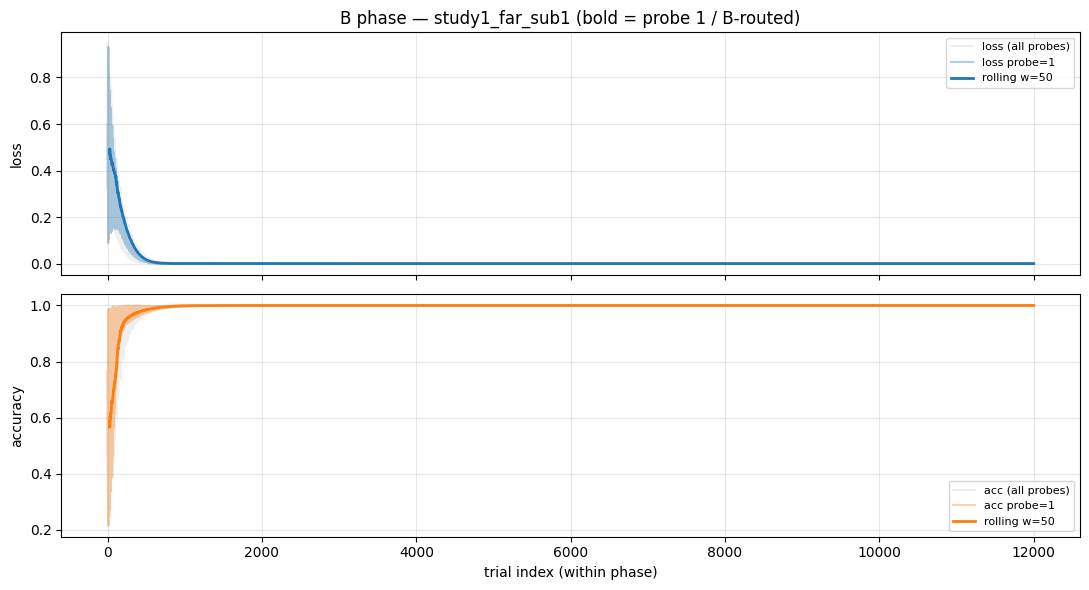

Median ||h_A||/||h_B|| in B phase — all valid trials: 1.8702 | probe==1 only: 0.1871


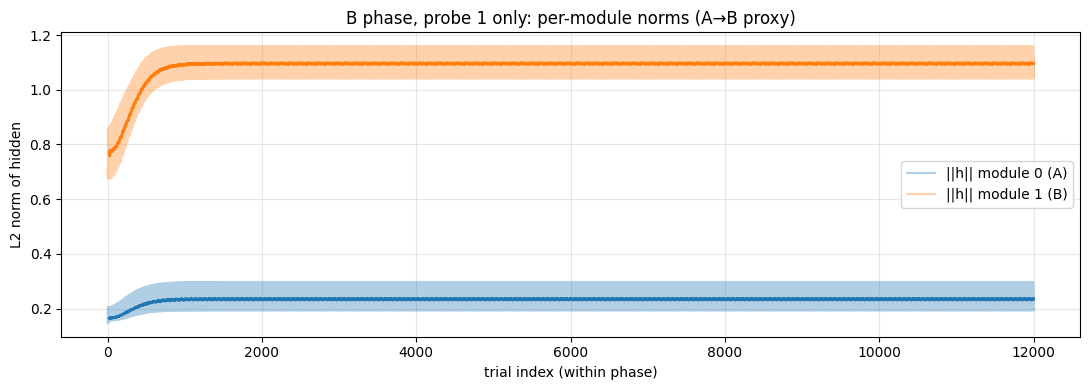

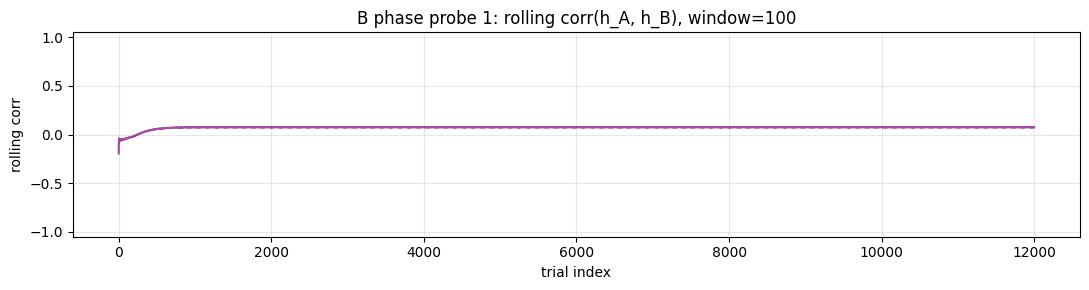

In [5]:
phase = PHASE_B
m = trial_mask_1d(losses[phase])
pr_b = probes[phase, m].astype(int)
u, cts = np.unique(pr_b, return_counts=True)
print(f"B phase: {int(m.sum())} valid trials — probe counts: {dict(zip(u.tolist(), cts.tolist()))}")

m1 = m & (probes[phase] == 1)
idx1 = np.where(m1)[0]
loss_1 = losses[phase, m1]
acc_1 = acc[phase, m1]
w = min(50, max(5, max(len(loss_1), 1) // 20))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
# Context: all valid trials (faded)
if m.sum() > m1.sum():
    idx_all = np.where(m)[0]
    axes[0].plot(idx_all, losses[phase, m], alpha=0.12, color="gray", label="loss (all probes)")
    axes[1].plot(idx_all, acc[phase, m], alpha=0.12, color="gray", label="acc (all probes)")
# Primary: probe 1
axes[0].plot(idx1, loss_1, alpha=0.35, color="C0", label="loss probe=1")
axes[0].plot(idx1, rolling_mean(loss_1, w), color="C0", lw=2, label=f"rolling w={w}")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title(f"B phase — {PARTICIPANT_ID} (bold = probe 1 / B-routed)")

axes[1].plot(idx1, acc_1, alpha=0.35, color="C1", label="acc probe=1")
axes[1].plot(idx1, rolling_mean(acc_1, w), color="C1", lw=2, label=f"rolling w={w}")
axes[1].set_ylabel("accuracy")
axes[1].set_xlabel("trial index (within phase)")
axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

if hpm is not None and m1.sum() > 0:
    h_all = hpm[phase, m]
    n0_all = np.linalg.norm(h_all[:, MOD_A, :], axis=1)
    n1_all = np.linalg.norm(h_all[:, MOD_B, :], axis=1)
    ratio_all = float(np.nanmedian(n0_all / (n1_all + 1e-8)))

    h = hpm[phase, m1]
    n0 = np.linalg.norm(h[:, MOD_A, :], axis=1)
    n1 = np.linalg.norm(h[:, MOD_B, :], axis=1)
    ratio_1 = float(np.nanmedian(n0 / (n1 + 1e-8)))
    print(f"Median ||h_A||/||h_B|| in B phase — all valid trials: {ratio_all:.4f} | probe==1 only: {ratio_1:.4f}")

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(idx1, n0, alpha=0.35, label=f"||h|| module {MOD_A} (A)")
    ax.plot(idx1, n1, alpha=0.35, label=f"||h|| module {MOD_B} (B)")
    ax.plot(idx1, rolling_mean(n0, w), color="C0", lw=2)
    ax.plot(idx1, rolling_mean(n1, w), color="C1", lw=2)
    ax.set_xlabel("trial index (within phase)")
    ax.set_ylabel("L2 norm of hidden")
    ax.set_title("B phase, probe 1 only: per-module norms (A→B proxy)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    flat0 = h[:, MOD_A, :].reshape(h.shape[0], -1)
    flat1 = h[:, MOD_B, :].reshape(h.shape[0], -1)
    win = min(100, max(20, len(h) // 15))
    cors = []
    for t in range(len(h)):
        s = slice(max(0, t - win + 1), t + 1)
        a, b = flat0[s].ravel(), flat1[s].ravel()
        if a.size < 10:
            cors.append(np.nan)
            continue
        if np.std(a) < 1e-8 or np.std(b) < 1e-8:
            cors.append(np.nan)
        else:
            cors.append(np.corrcoef(a, b)[0, 1])
    cors = np.array(cors)
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(idx1, cors, color="purple", alpha=0.7)
    ax.set_ylim(-1.05, 1.05)
    ax.set_xlabel("trial index")
    ax.set_ylabel("rolling corr")
    ax.set_title(f"B phase probe 1: rolling corr(h_A, h_B), window={win}")
    plt.tight_layout()
    plt.show()
elif hpm is not None:
    print("No probe==1 trials in B phase; skip norm/corr plots.")

## Focus 2 — A2 phase: probe 0 (updates) vs probe 1 (eval only)

**Probe 0:** loss backprop into A pathway. **Probe 1:** still forward through both modules / readout — useful to see **B→A** leakage into representations and metrics without direct gradient on that trial type.

probe 0: n=6000  mean loss=0.00030  mean acc=0.9996
probe 1: n=6000  mean loss=0.16809  mean acc=0.8453


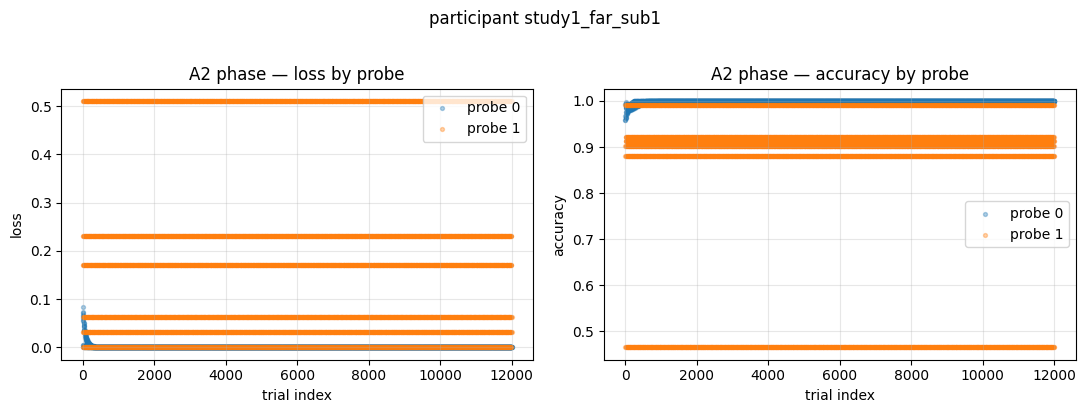

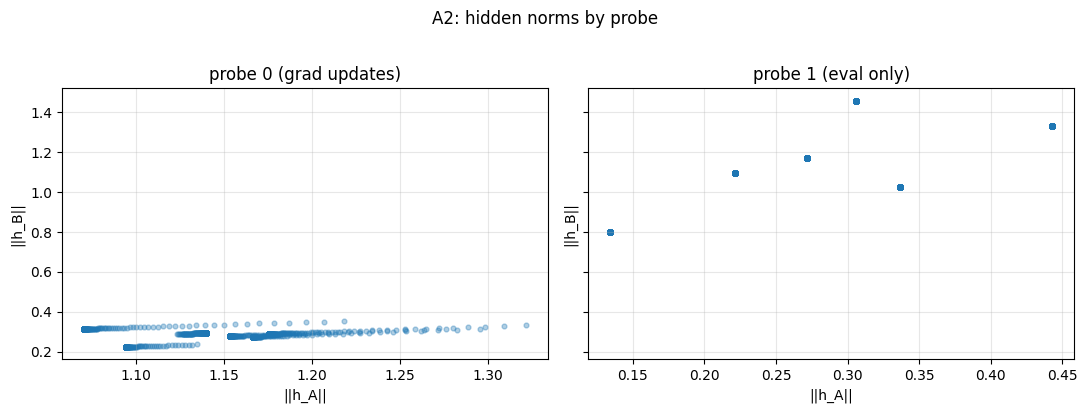

In [6]:
phase = PHASE_A2
m = trial_mask_1d(losses[phase])
loss_a2 = losses[phase, m]
acc_a2 = acc[phase, m]
pr = probes[phase, m].astype(int)
idx = np.where(m)[0]

for pval in (0, 1):
    sub = pr == pval
    print(
        f"probe {pval}: n={sub.sum()}  mean loss={np.nanmean(loss_a2[sub]):.5f}  mean acc={np.nanmean(acc_a2[sub]):.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, y in zip(axes, ["loss", "accuracy"], [loss_a2, acc_a2]):
    for pval, c in [(0, "C0"), (1, "C1")]:
        sub = pr == pval
        ax.scatter(idx[sub], y[sub], s=8, alpha=0.35, c=c, label=f"probe {pval}")
    ax.set_xlabel("trial index")
    ax.set_ylabel(name)
    ax.set_title(f"A2 phase — {name} by probe")
    ax.legend()
plt.suptitle(f"participant {PARTICIPANT_ID}", y=1.02)
plt.tight_layout()
plt.show()

if hpm is not None:
    h = hpm[phase, m]
    n0 = np.linalg.norm(h[:, MOD_A, :], axis=1)
    n1 = np.linalg.norm(h[:, MOD_B, :], axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, pval, title in zip(
        axes,
        [0, 1],
        ["probe 0 (grad updates)", "probe 1 (eval only)"],
    ):
        sub = pr == pval
        if sub.sum() == 0:
            ax.set_title(title + "\n(no trials)")
            continue
        ax.scatter(n0[sub], n1[sub], alpha=0.35, s=12)
        ax.set_xlabel("||h_A||")
        ax.set_ylabel("||h_B||")
        ax.set_title(title)
    plt.suptitle("A2: hidden norms by probe", y=1.02)
    plt.tight_layout()
    plt.show()

## Focus 3 — Post-phase core vs comms (ordered sweep)

If keys exist: compare L2 norm of **core** vs **comms** per module at end of each phase. Large comms after B suggests inter-module pathway use on the probe stimulus set.

In [7]:
def summarize_core_comms(d, phase_idx):
    ck = f"hiddens_post_phase_{phase_idx}_core_per_module"
    vk = f"hiddens_post_phase_{phase_idx}_comms_per_module"
    if ck not in d or vk not in d:
        return None
    core = d[ck]  # (n_stim, n_mod, h) or similar
    comms = d[vk]
    rows = []
    for name, arr in [("core", core), ("comms", comms)]:
        a = np.asarray(arr, dtype=float)
        if a.ndim == 3:
            for m in range(a.shape[1]):
                rows.append(
                    {
                        "phase": phase_idx,
                        "part": name,
                        "module": m,
                        "mean_L2": np.nanmean(np.linalg.norm(a[:, m, :], axis=1)),
                    }
                )
    return pd.DataFrame(rows)


frames = []
for ph in (0, 1, 2):
    df_cc = summarize_core_comms(data, ph)
    if df_cc is not None:
        frames.append(df_cc)

if not frames:
    print("No core/comms keys in this npz (older run or different arch).")
else:
    cc_df = pd.concat(frames, ignore_index=True)
    display(cc_df.pivot_table(index=["phase", "module"], columns="part", values="mean_L2"))
    pivot = cc_df.pivot_table(index=["phase", "module"], columns="part", values="mean_L2")
    if "comms" in pivot.columns and "core" in pivot.columns:
        pivot = pivot.copy()
        pivot["comms_to_core"] = pivot["comms"] / (pivot["core"] + 1e-8)
        display(pivot)

No core/comms keys in this npz (older run or different arch).


## Interpretation rubric (quick)

| Observation | Possible reading |
|-------------|------------------|
| **Quick overview** table: spread of `b_median_hA_over_hB_probe1` vs `..._all` | Large gap ⇒ mixed probes confound “all B trials”; prioritize **probe-1** column for A→B |
| B phase **probe 1**: `||h_A||` vs `||h_B||`, or rolling corr away from 0 | Recurrence couples modules during B-routed input → **A→B signal worth modeling** |
| B phase probe 1: `||h_A||` ≪ `||h_B||` and corr ~ 0 | Weak **amplitude** coupling; may still have subtle gradient / directional effects |
| A2: large loss/acc gap between probe 0 vs 1 | Task/readout asymmetry; **B-side** trials still drive different behavior |
| A2: `||h_B||` high on probe-0 vs probe-1 scatter | B module engaged differently when A is trained vs when only evaluated |
| Post-phase: comms/core rises after B | Pathways used on sweep stimuli after B training |

**Next if signal is weak:** subsample `return_core_comms` during training, or checkpoint ablations; compare **no_comms** vs **full** runs on the same metrics above.